In [1]:
!whoami
!echo 24BAD405 EX06a

nishanth\nishanth
24BAD405 EX06a


In [9]:
import random
import time
import matplotlib.pyplot as plt
from typing import Tuple, List

In [10]:
def max_subarray_brute_force(arr: List[int]) -> Tuple[int, int, int]:
    """
    Brute Force - O(n³) time
    Returns: (max_sum, start_index, end_index)
    """
    if not arr:
        return 0, -1, -1
        
    n = len(arr)
    max_sum = float('-inf')
    best_start = best_end = -1
    
    for i in range(n):
        for j in range(i, n):
            current_sum = 0
            for k in range(i, j+1):
                current_sum += arr[k]
            if current_sum > max_sum:
                max_sum = current_sum
                best_start = i
                best_end = j
                
    return max_sum, best_start, best_end

In [11]:

def max_subarray_divide_conquer(arr: List[int]) -> Tuple[int, int, int]:
    """
    Divide and Conquer - O(n log n) time
    Returns: (max_sum, start_index, end_index)
    """
    def conquer(left: int, right: int) -> Tuple[int, int, int, int, int]:
     
        if left == right:
            val = arr[left]
            return val, val, val, val, (left, left)
            
        mid = (left + right) // 2
        
        left_total, left_prefix, left_suffix, left_max, left_indices = conquer(left, mid)
        right_total, right_prefix, right_suffix, right_max, right_indices = conquer(mid+1, right)
        
        cross_sum = left_suffix + right_prefix
        

        if left_max >= right_max and left_max >= cross_sum:
            max_sum = left_max
            best_indices = left_indices
        elif right_max >= cross_sum:
            max_sum = right_max
            best_indices = right_indices
        else:
            max_sum = cross_sum
            best_indices = (left_indices[0], right_indices[1]) 
            
        total = left_total + right_total
        
        max_prefix = max(left_prefix, left_total + right_prefix)
        
        max_suffix = max(right_suffix, right_total + left_suffix)
        
        return total, max_prefix, max_suffix, max_sum, best_indices
    
    if not arr:
        return 0, -1, -1
        
    _, _, _, max_sum, (start, end) = conquer(0, len(arr)-1)
    return max_sum, start, end

In [12]:

def max_subarray_kadane(arr: List[int]) -> Tuple[int, int, int]:
    """
    Kadane's algorithm - O(n) time (for reference & verification)
    """
    if not arr:
        return 0, -1, -1
        
    max_ending_here = max_so_far = arr[0]
    start = end = temp_start = 0
    
    for i in range(1, len(arr)):
        if arr[i] > max_ending_here + arr[i]:
            max_ending_here = arr[i]
            temp_start = i
        else:
            max_ending_here += arr[i]
            
        if max_ending_here > max_so_far:
            max_so_far = max_ending_here
            start = temp_start
            end = i
            
    return max_so_far, start, end

In [13]:

def test_max_subarray():
    test_cases = [
        [-2, 1, -3, 4, -1, 2, 1, -5, 4],         
        [1, -2, 3, 10, -4, 7, 2, -5], 
        [-1, -2, -3, -4],
        [5],
        [-2, -3, 4, -1, -2, 1, 5, -3],
        list(range(-10, 15)) + list(range(10, -15, -1))
    ]
    
    print("VERIFICATION RESULTS")
    
    for idx, arr in enumerate(test_cases, 1):
        bf_sum, bf_s, bf_e = max_subarray_brute_force(arr)
        dc_sum, dc_s, dc_e = max_subarray_divide_conquer(arr)
        kd_sum, kd_s, kd_e = max_subarray_kadane(arr)
        
        print(f"\nTest {idx}:")
        print(f"  Array : {arr}")
        print(f"  Brute : sum={bf_sum:4d}  [{bf_s}..{bf_e}]")
        print(f"  D&C   : sum={dc_sum:4d}  [{dc_s}..{dc_e}]")
        print(f"  Kadane: sum={kd_sum:4d}  [{kd_s}..{kd_e}]")
        
        if not (bf_sum == dc_sum == kd_sum):
            print("  !!! INCONSISTENT RESULT !!!")

In [14]:


def performance_comparison():
    sizes = [10, 50, 100, 250, 500]
    bf_times = []
    dc_times = []
    

    print("PERFORMANCE COMPARISON")

    
    for n in sizes:
        arr = [random.randint(-100, 100) for _ in range(n)]
        
        t1 = time.perf_counter()
        max_subarray_brute_force(arr)
        t2 = time.perf_counter()
        bf_time = (t2 - t1) * 1000  # ms
        
        t1 = time.perf_counter()
        max_subarray_divide_conquer(arr)
        t2 = time.perf_counter()
        dc_time = (t2 - t1) * 1000  # ms
        
        bf_times.append(bf_time)
        dc_times.append(dc_time)
        
        print(f"n = {n:4d} | Brute: {bf_time:8.3f} ms | D&C: {dc_time:8.3f} ms | ratio: {bf_time/dc_time:6.1f}x")
        
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, bf_times, 'o-', label='Brute Force (O(n³))', linewidth=2)
    plt.plot(sizes, dc_times, 's-', label='Divide & Conquer (O(n log n))', linewidth=2)
    plt.xlabel('Input size (n)')
    plt.ylabel('Execution time (ms)')
    plt.title('Maximum Subarray Sum: Brute Force vs Divide & Conquer')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.xscale('log')
    plt.show()
    

Maximum Subarray Sum Implementations

VERIFICATION RESULTS

Test 1:
  Array : [-2, 1, -3, 4, -1, 2, 1, -5, 4]
  Brute : sum=   6  [3..6]
  D&C   : sum=   6  [3..8]
  Kadane: sum=   6  [3..6]

Test 2:
  Array : [1, -2, 3, 10, -4, 7, 2, -5]
  Brute : sum=  18  [2..6]
  D&C   : sum=  18  [2..6]
  Kadane: sum=  18  [2..6]

Test 3:
  Array : [-1, -2, -3, -4]
  Brute : sum=  -1  [0..0]
  D&C   : sum=  -1  [0..0]
  Kadane: sum=  -1  [0..0]

Test 4:
  Array : [5]
  Brute : sum=   5  [0..0]
  D&C   : sum=   5  [0..0]
  Kadane: sum=   5  [0..0]

Test 5:
  Array : [-2, -3, 4, -1, -2, 1, 5, -3]
  Brute : sum=   7  [2..6]
  D&C   : sum=   7  [2..6]
  Kadane: sum=   7  [2..6]

Test 6:
  Array : [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14]
  Brute : sum= 160  [10..34]
  D&C   : sum= 160  [11..34]
  Kadane: sum= 160  [10..34]
PERFORMANCE COMPARISON
n =   10 | Br

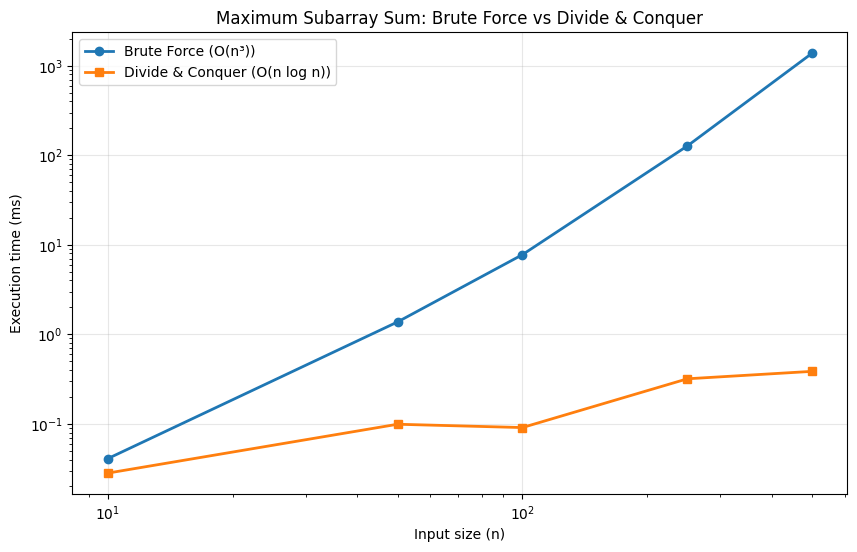

In [15]:
if __name__ == "__main__":
    print("Maximum Subarray Sum Implementations\n")
    
    test_max_subarray()
    
    performance_comparison()